# The Inverse Matrix

*Course notes for **Math for Machine Learning**, C1 · W3 · L2 · V05 — "The Inverse Matrix" (DeepLearning.AI).*

Just as a number has an inverse — $2^{-1} = \tfrac12$, $(-5)^{-1} = -\tfrac15$ — a matrix can have an **inverse matrix**. Where the number inverse multiplies to give **$1$**, the matrix inverse multiplies to give the **identity matrix**. As a transformation, the inverse **undoes** the original, returning the plane to where it started. We cover:

- The definition $M M^{-1} = I$ and the "undo" picture.
- **Finding** the inverse by solving a system of linear equations.
- When an inverse **does not exist** (singular matrices).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. Definition: $M M^{-1} = I$

The inverse of $M$, written $M^{-1}$, is the matrix for which the product is the **identity**:

$$ M\,M^{-1} = M^{-1} M = I. $$

For the familiar matrix $M = \begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix}$, the inverse turns out to be

$$ M^{-1} = \begin{pmatrix} \tfrac{2}{5} & -\tfrac{1}{5} \\ -\tfrac{1}{5} & \tfrac{3}{5} \end{pmatrix}. $$

In [2]:
M = np.array([[3, 1],
              [1, 2]])
Minv = np.linalg.inv(M)
print('M^-1 =')
print(Minv)
print()
print('M @ M^-1 =')
print(M @ Minv)                       # -> identity
print('is identity:', np.allclose(M @ Minv, np.eye(2)))

M^-1 =
[[ 0.4 -0.2]
 [-0.2  0.6]]

M @ M^-1 =
[[1. 0.]
 [0. 1.]]
is identity: True


## 2. The inverse undoes the transformation

$M$ turns the unit square into a parallelogram; $M^{-1}$ turns that parallelogram **back** into the original square. Composing the two gives the identity — the transformation that does nothing.

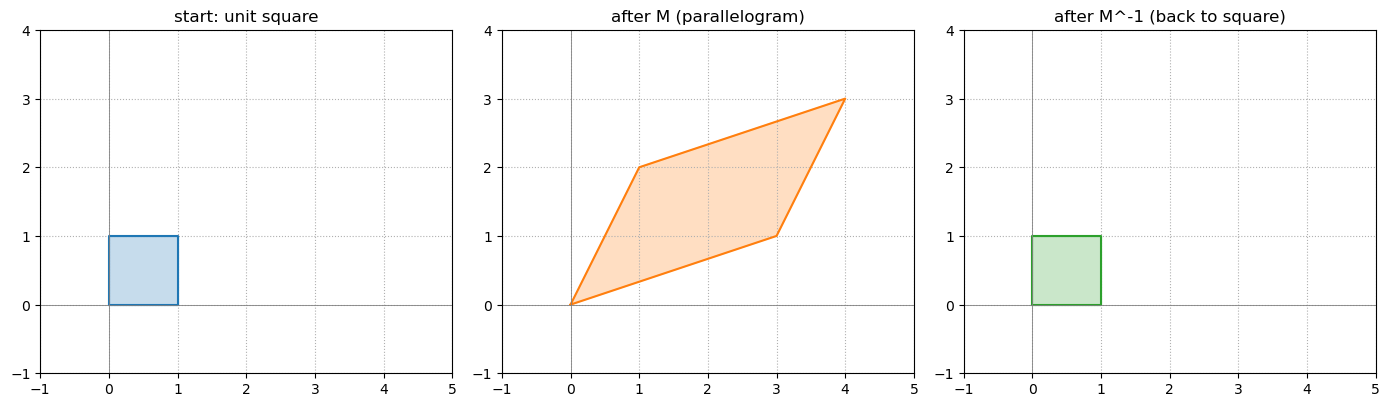

recovered the square: True


In [3]:
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
img = M @ square              # after M
back = Minv @ img             # after M^-1  (== original square)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, S, ttl, col in [(axes[0], square, 'start: unit square', 'C0'),
                        (axes[1], img, 'after M (parallelogram)', 'C1'),
                        (axes[2], back, 'after M^-1 (back to square)', 'C2')]:
    ax.fill(S[0], S[1], color=col, alpha=0.25); ax.plot(S[0], S[1], color=col)
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_title(ttl)
    ax.set_xlim(-1, 5); ax.set_ylim(-1, 4)
plt.tight_layout(); plt.show()

print('recovered the square:', np.allclose(back, square))

## 3. Finding the inverse by solving a linear system

Write the unknown inverse as $\begin{pmatrix} a & b \\ c & d \end{pmatrix}$ and demand $M M^{-1} = I$. Matching the four entries gives **four dot-product equations** in the four unknowns:

$$ \begin{aligned} 3a + c &= 1 & 3b + d &= 0 \\ a + 2c &= 0 & b + 2d &= 1 \end{aligned} $$

Solving by elimination gives $a=\tfrac25,\; b=-\tfrac15,\; c=-\tfrac15,\; d=\tfrac35$. Notation: the inverse is written $M^{-1}$, exactly as $2^{-1}=\tfrac12$.

In [4]:
# Solve M X = I column by column (this IS solving the 4-equation system)
col1 = np.linalg.solve(M, np.array([1, 0]))   # a, c
col2 = np.linalg.solve(M, np.array([0, 1]))   # b, d
print('a, c =', col1)     # [0.4, -0.2]  = 2/5, -1/5
print('b, d =', col2)     # [-0.2, 0.6]  = -1/5, 3/5
print('assembled inverse =')
print(np.column_stack([col1, col2]))

a, c = [ 0.4 -0.2]
b, d = [-0.2  0.6]
assembled inverse =
[[ 0.4 -0.2]
 [-0.2  0.6]]


**Quiz from the video.** The inverse of $\begin{pmatrix} 5 & 2 \\ 1 & 2 \end{pmatrix}$ is $\begin{pmatrix} \tfrac14 & -\tfrac14 \\ -\tfrac18 & \tfrac58 \end{pmatrix}$.

In [5]:
Q = np.array([[5, 2],
              [1, 2]])
print('inv(Q) =')
print(np.linalg.inv(Q))            # [[0.25, -0.25], [-0.125, 0.625]]

inv(Q) =
[[ 0.25  -0.25 ]
 [-0.125  0.625]]


## 4. When the inverse does not exist

Not every matrix has an inverse. Consider $\begin{pmatrix} 1 & 1 \\ 2 & 2 \end{pmatrix}$. Setting up $M M^{-1} = I$ gives the system

$$ a + c = 1, \quad 2a + 2c = 0, \quad b + d = 1, \quad 2b + 2d = 0. $$

The first two **contradict** each other: if $a + c = 1$ then $2a + 2c$ must be $2$, not $0$. There is **no solution**, so the matrix has **no inverse** — it is *singular*. (Its rows are proportional and its **determinant is $0$**, the tell-tale sign.)

In [6]:
S = np.array([[1, 1],
              [2, 2]])
print('det(S) =', np.linalg.det(S))   # 0  -> singular, no inverse
try:
    np.linalg.inv(S)
except np.linalg.LinAlgError as e:
    print('np.linalg.inv error:', e)

det(S) = 0.0
np.linalg.inv error: Singular matrix


## Summary

- The **inverse matrix** $M^{-1}$ satisfies $M M^{-1} = M^{-1} M = I$ — the matrix version of $2^{-1}=\tfrac12$.
- As a **transformation**, $M^{-1}$ **undoes** $M$, returning the plane to its original state; their composition is the identity.
- You **find** it by solving a linear system (demanding $M M^{-1} = I$), e.g. `np.linalg.solve` per column, or directly with `np.linalg.inv`.
- An inverse **doesn't always exist**: if the system is contradictory the matrix is **singular** — equivalently, its **determinant is $0$** — and `np.linalg.inv` raises `LinAlgError`.